In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import pickle
import joblib
import numpy as np

import sinter
import os

from qecsim.lattice_surgery.circuit import surgery_circuit
from qecsim.threshold_num.calc_threshold_new import calc_threshold_new
from qecsim.threshold_num.calc_threshold import threshold_approx

Adding the Observables manually doesn't really work. Stim therefore has a function called solve_flow_measurements:
<br>
<br>
    -> Implements the observables who satisfy needed flow i.e. X1 -> X1X2 in the normal CX case
<br>
    -> Keeps the corrective CZ/CX gates in mind

In [3]:
#surgery_circuit(distance = 3, round_num = 7, target_state_init="X+", control_state_init="X+", flow_observable = "X -> XX"). diagram("timeslice-svg")

In [6]:
# Load and concatenate all lists
stats_norm = joblib.load("lscx_singlerounds_combined.pkl")
stats_double = joblib.load("lscx_doublerounds_combined.pkl")
stats_3 = joblib.load("lscx_twothirdrounds_combined.pkl")
stats_double_merge = joblib.load("lscx_doublerounds_merge_combined.pkl")
stats_double_split = joblib.load("lscx_doublerounds_split_combined.pkl")
stats_3_merge = joblib.load("lscx_twothirdrounds_merge_combined.pkl")
stats_3_split = joblib.load("lscx_twothirdrounds_split_combined.pkl")
stats_double_init = joblib.load("lscx_doublerounds_init_combined.pkl")
stats_3_init = joblib.load("lscx_twothirdrounds_init_combined.pkl")


In [7]:
distances = sorted(set(stat.json_metadata["distance"] for stat in stats_norm))

red_dict_norm : dict = {}
red_dict_double : dict = {}
red_dict_3 : dict = {}
red_dict_double_merge : dict = {}
red_dict_3_merge : dict = {}
red_dict_double_split : dict = {}
red_dict_3_split : dict = {}
red_dict_double_init : dict = {}
red_dict_3_init : dict = {}

for d in range(0,len(distances)-1):
    red_dict_norm[distances[d]] = [stat for stat in stats_norm if stat.json_metadata["distance"] in {distances[d], distances[d+1]}]
    red_dict_double[distances[d]] = [stat for stat in stats_double if stat.json_metadata["distance"] in {distances[d], distances[d+1]}]
    red_dict_3[distances[d]] = [stat for stat in stats_3 if stat.json_metadata["distance"] in {distances[d], distances[d+1]}]
    red_dict_double_merge[distances[d]] = [stat for stat in stats_double_merge if stat.json_metadata["distance"] in {distances[d], distances[d+1]}]
    red_dict_3_merge[distances[d]] = [stat for stat in stats_3_merge if stat.json_metadata["distance"] in {distances[d], distances[d+1]}]
    red_dict_double_split[distances[d]] = [stat for stat in stats_double_split if stat.json_metadata["distance"] in {distances[d], distances[d+1]}]
    red_dict_3_split[distances[d]] = [stat for stat in stats_3_split if stat.json_metadata["distance"] in {distances[d], distances[d+1]}]
    red_dict_double_init[distances[d]] = [stat for stat in stats_double_init if stat.json_metadata["distance"] in {distances[d], distances[d+1]}]
    red_dict_3_init[distances[d]] = [stat for stat in stats_3_init if stat.json_metadata["distance"] in {distances[d], distances[d+1]}]

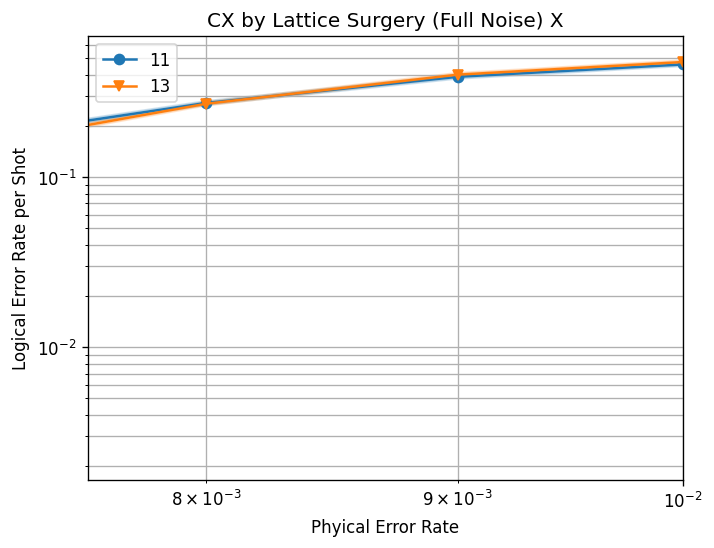

In [8]:
##################
# Plotting X Noise
##################

fig, ax = plt.subplots(1,1)
sinter.plot_error_rate(
    ax=ax,
    stats=red_dict_norm[11],
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['distance'])
ax.loglog()
ax.set_xlim(7.57e-3, 1e-2)
ax.set_title("CX by Lattice Surgery (Full Noise) X")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger

In [9]:
threshold_approx(red_dict_norm[5])

0.007579277212356521

<Figure size 640x480 with 0 Axes>

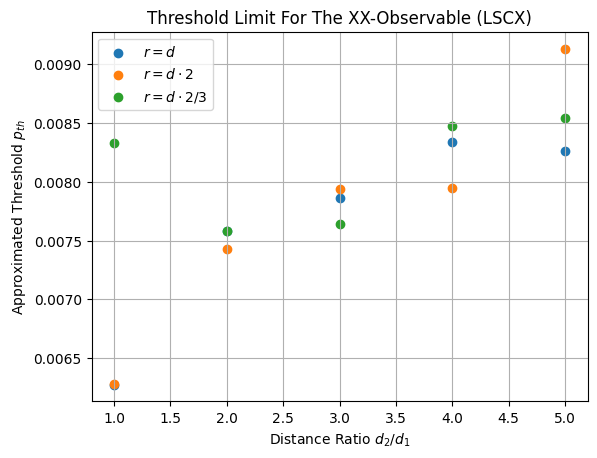

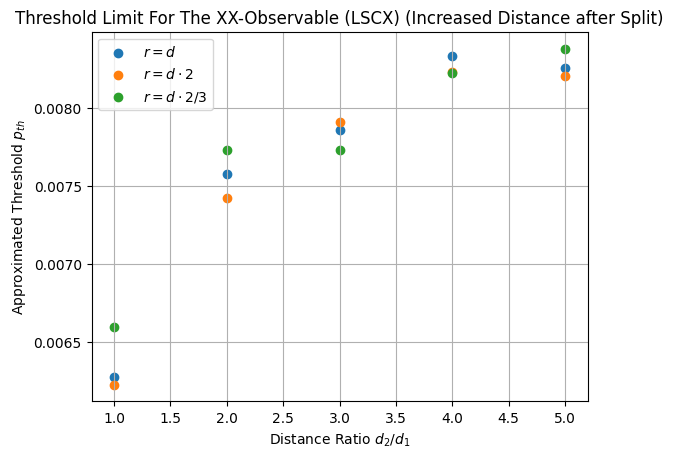

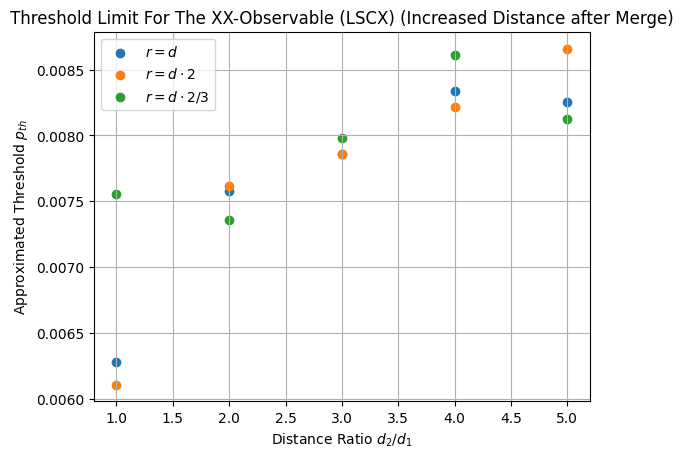

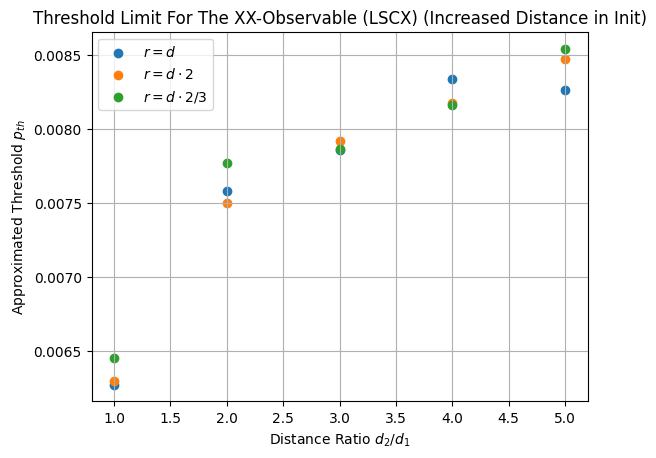

<Figure size 640x480 with 0 Axes>

In [9]:
data_array_norm = []
data_array_double = []
data_array_3 = []

##########################
# Approx with first method
##########################

for pos, i in enumerate(distances[:-1]):
    try:
        data_array_norm.append([threshold_approx(red_dict_norm[i], p_max = 1e-2, p_min = 5e-3), pos + 1])
    except Exception as e:
        print(f"norm d={i} failed: {e}")

    try:
        data_array_double.append([threshold_approx(red_dict_double[i], p_max = 1e-2, p_min = 5e-3), pos + 1])
    except Exception as e:
        print(f"double d={i} failed: {e}")

    try:
        data_array_3.append([threshold_approx(red_dict_3[i], p_max = 1e-2, p_min = 5e-3), pos + 1])
    except Exception as e:
        print(f"twothird d={i} failed: {e}")


x_vals_norm = [point[1] for point in data_array_norm]
y_vals_norm = [point[0] for point in data_array_norm]
x_vals_double = [point[1] for point in data_array_double]
y_vals_double = [point[0] for point in data_array_double]
x_vals_3 = [point[1] for point in data_array_3]
y_vals_3 = [point[0] for point in data_array_3]


plt.scatter(x_vals_norm, y_vals_norm, label = "$r=d$")
plt.scatter(x_vals_double, y_vals_double, label = "$r = d \\cdot 2$")
plt.scatter(x_vals_3, y_vals_3, label = "$r = d \\cdot 2/3$")
plt.ylabel("Approximated Threshold $p_{th}$")
plt.xlabel("Distance Ratio $d_2/d_1$")
plt.title("Threshold Limit For The XX-Observable (LSCX)")
plt.legend()
plt.grid(True)

plt.figure()

#####################################
# Plot for Distance increase in Split
#####################################

data_array_norm = []
data_array_double_split = []
data_array_3_split = []

##########################
# Approx with first method
##########################

for pos, i in enumerate(distances[:-1]):
    try:
        data_array_norm.append([threshold_approx(red_dict_norm[i], p_max = 1e-2, p_min = 5e-3), pos + 1])
    except Exception as e:
        print(f"norm d={i} failed: {e}")

    try:
        data_array_double_split.append([threshold_approx(red_dict_double_split[i], p_max = 1e-2, p_min = 5e-3), pos + 1])
    except Exception as e:
        print(f"double d={i} failed: {e}")

    try:
        data_array_3_split.append([threshold_approx(red_dict_3_split[i], p_max = 1e-2, p_min = 5e-3), pos + 1])
    except Exception as e:
        print(f"twothird d={i} failed: {e}")


x_vals_norm = [point[1] for point in data_array_norm]
y_vals_norm = [point[0] for point in data_array_norm]
x_vals_double_split = [point[1] for point in data_array_double_split]
y_vals_double_split = [point[0] for point in data_array_double_split]
x_vals_3_split = [point[1] for point in data_array_3_split]
y_vals_3_split = [point[0] for point in data_array_3_split]


plt.scatter(x_vals_norm, y_vals_norm, label = "$r=d$")
plt.scatter(x_vals_double_split, y_vals_double_split, label = "$r = d \\cdot 2$")
plt.scatter(x_vals_3_split, y_vals_3_split, label = "$r = d \\cdot 2/3$")
plt.ylabel("Approximated Threshold $p_{th}$")
plt.xlabel("Distance Ratio $d_2/d_1$")
plt.title("Threshold Limit For The XX-Observable (LSCX) (Increased Distance after Split)")
plt.legend()
plt.grid(True)

plt.figure()

#####################################
# Plot for Distance increase in Merge
#####################################

data_array_norm = []
data_array_double_merge = []
data_array_3_merge = []

##########################
# Approx with first method
##########################

for pos, i in enumerate(distances[:-1]):
    try:
        data_array_norm.append([threshold_approx(red_dict_norm[i], p_max = 1e-2, p_min = 5e-3), pos + 1])
    except Exception as e:
        print(f"norm d={i} failed: {e}")

    try:
        data_array_double_merge.append([threshold_approx(red_dict_double_merge[i], p_max = 1e-2, p_min = 5e-3), pos + 1])
    except Exception as e:
        print(f"double d={i} failed: {e}")

    try:
        data_array_3_merge.append([threshold_approx(red_dict_3_merge[i], p_max = 1e-2, p_min = 5e-3), pos + 1])
    except Exception as e:
        print(f"twothird d={i} failed: {e}")


x_vals_norm = [point[1] for point in data_array_norm]
y_vals_norm = [point[0] for point in data_array_norm]
x_vals_double_merge = [point[1] for point in data_array_double_merge]
y_vals_double_merge = [point[0] for point in data_array_double_merge]
x_vals_3_merge = [point[1] for point in data_array_3_merge]
y_vals_3_merge = [point[0] for point in data_array_3_merge]


plt.scatter(x_vals_norm, y_vals_norm, label = "$r=d$")
plt.scatter(x_vals_double_merge, y_vals_double_merge, label = "$r = d \\cdot 2$")
plt.scatter(x_vals_3_merge, y_vals_3_merge, label = "$r = d \\cdot 2/3$")
plt.ylabel("Approximated Threshold $p_{th}$")
plt.xlabel("Distance Ratio $d_2/d_1$")
plt.title("Threshold Limit For The XX-Observable (LSCX) (Increased Distance after Merge)")
plt.legend()
plt.grid(True)

plt.figure()

####################################
# Plot for Distance increase in Init
####################################

data_array_norm = []
data_array_double_init = []
data_array_3_init = []

##########################
# Approx with first method
##########################

for pos, i in enumerate(distances[:-1]):
    try:
        data_array_norm.append([threshold_approx(red_dict_norm[i], p_max = 1e-2, p_min = 5e-3), pos + 1])
    except Exception as e:
        print(f"norm d={i} failed: {e}")

    try:
        data_array_double_init.append([threshold_approx(red_dict_double_init[i], p_max = 1e-2, p_min = 5e-3), pos + 1])
    except Exception as e:
        print(f"double d={i} failed: {e}")

    try:
        data_array_3_init.append([threshold_approx(red_dict_3_init[i], p_max = 1e-2, p_min = 5e-3), pos + 1])
    except Exception as e:
        print(f"twothird d={i} failed: {e}")


x_vals_norm = [point[1] for point in data_array_norm]
y_vals_norm = [point[0] for point in data_array_norm]
x_vals_double_init = [point[1] for point in data_array_double_init]
y_vals_double_init = [point[0] for point in data_array_double_init]
x_vals_3_init = [point[1] for point in data_array_3_init]
y_vals_3_init = [point[0] for point in data_array_3_init]


plt.scatter(x_vals_norm, y_vals_norm, label = "$r=d$")
plt.scatter(x_vals_double_init, y_vals_double_init, label = "$r = d \\cdot 2$")
plt.scatter(x_vals_3_init, y_vals_3_init, label = "$r = d \\cdot 2/3$")
plt.ylabel("Approximated Threshold $p_{th}$")
plt.xlabel("Distance Ratio $d_2/d_1$")
plt.title("Threshold Limit For The XX-Observable (LSCX) (Increased Distance in Init)")
plt.legend()
plt.grid(True)

plt.figure()